In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from datetime import timedelta
from ipywidgets import interact, widgets
from IPython.display import display

In [2]:
%load_ext autoreload

In [3]:
#Run this to reload the python file
%autoreload 2
from utils import *

# Preprocess data

In [4]:
# metadata form long term analysis
meta_df = pd.read_csv('./Data/metadata/long_term_v07.csv')

In [16]:
# delete the unnecessary columns
meta_df = meta_df.drop(columns=['1D', '7D', '1M', 'diff_accum','percentage_diff'])

In [6]:
# import long term data
imn_df = pd.read_csv('./Data/harmonized/unif_IMN.csv')
gpm_df = pd.read_csv('./Data/harmonized/unif_GPM.csv')

In [7]:
# assigning 'date' as index
imn_df = convert_index(imn_df, 'date')
gpm_df = convert_index(gpm_df, 'date')

In [8]:
# select interest dates -> NATE
imn_df = imn_df['2017-10-04 00:00:00':'2017-10-06 23:00:00']
gpm_df = gpm_df['2017-10-04 00:00:00':'2017-10-06 23:00:00']

In [9]:
# delete the unnecessary columns 
imn_df = imn_df.drop(
    columns=[
        '84141', '69679', '73123', '71015', '84139', '81005', '84191', '84169', '69633', '84197', '84187', '69681'
        ]
        )

gpm_df = gpm_df.drop(
    columns=[
        '84141', '69679', '73123', '71015', '84139', '81005', '84191', '84169', '69633', '84197', '84187', '69681'
        ]
        )

In [11]:
gpm_df.to_csv('./Data/harmonized/unif_gpm_ST_v2.csv')

In [12]:
imn_df.to_csv('./Data/harmonized/unif_imn_ST_v2.csv')

# Import data

In [4]:
# import short term data
imn_df = pd.read_csv('./Data/harmonized/unif_imn_ST_v2.csv')
gpm_df = pd.read_csv('./Data/harmonized/unif_gpm_ST_v2.csv')

In [5]:
# assigning 'date' as index
imn_df = convert_index(imn_df, 'date')
gpm_df = convert_index(gpm_df, 'date')

In [6]:
# import metadata
meta_df = pd.read_csv('./Data/metadata/short_term_v07_v2.csv')

In [7]:
temp_resol = {
    '1H': '1 hora',
    '3H': '3 horas',
    '6H': '6 horas'
}

# Analysis

### Correlations

In [17]:
corr_temp = []
for window in temp_resol.keys():
    tmp = corr_accum(imn_df, gpm_df, window)
    result_dict = {
        'window': window,
        'correlation': tmp.get('correlation')
    }
    corr_temp.append(result_dict)

In [18]:
df = pd.DataFrame()
df['1H'] = corr_temp[0]['correlation']
df['3H'] = corr_temp[1]['correlation']
df['6H'] = corr_temp[2]['correlation']

In [19]:
df = df.reset_index()
df.rename(columns={'index': 'numero'}, inplace=True)

In [20]:
df['numero'] = df['numero'].astype(float)

In [21]:
meta_df = pd.merge(meta_df, df, left_on='Número', right_on='numero')

In [22]:
meta_df = meta_df.drop(columns=['numero','Unnamed: 0'])

### Difference between accumulated

In [19]:
# List to store dictionaries
result_list = []

# Loop through columns and append results to the list
for number in imn_df.columns:
    result_dict = diff_accum(imn_df, gpm_df, number)
    result_list.append(result_dict)

# Convert the list of dictionaries into a DataFrame
accumulated_diff = pd.DataFrame(result_list)

In [20]:
accumulated_diff['number'] = accumulated_diff['number'].astype(float)

In [21]:
meta_df = pd.merge(meta_df, accumulated_diff, left_on='Número', right_on='number')

In [22]:
meta_df = meta_df.drop(columns=['number'])

In [24]:
meta_df.to_csv('./Data/metadata/short_term_v07_v2.csv')

# Plotting

## Short term

### Time Series

In [8]:
# Create a dropdown widget for selecting the column
column_options = list(imn_df.columns)  # Assuming both dataframes have the same columns
column_dropdown = widgets.Dropdown(
    options=column_options,
    value=column_options[0],
    description='Station Number:',
    disabled=False
)

In [9]:
# Create a dropdown widget for selecting resolution
resolution_options = list(temp_resol.keys()) 
resolution_dropdown = widgets.Dropdown(
    options=resolution_options,
    value=resolution_options[0],
    description='Resolution:',
    disabled=False
)

In [10]:
# Create an interactive plot
interactive_plot = widgets.interactive(
    plot_resol,
    df1=widgets.fixed(imn_df),
    df2=widgets.fixed(gpm_df),
    resolution=resolution_dropdown,
    column=column_dropdown
)

# Display the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Resolution:', options=('1H', '3H', '6H'), value='1H'), Dropdown(de…

### Correlations

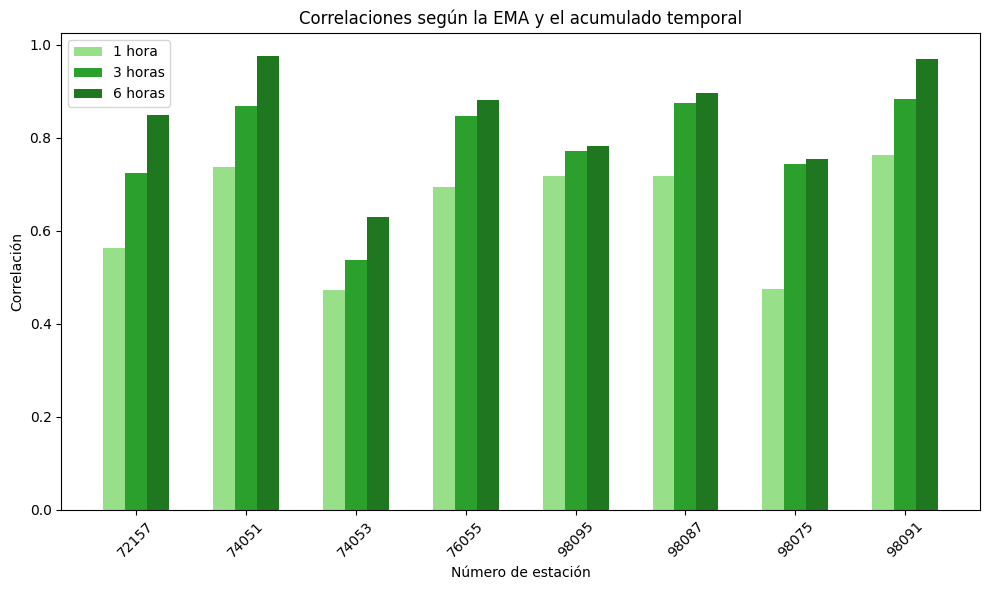

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width can be adjusted based on preference
bar_width = 0.2
bar_positions = np.arange(len(meta_df['Número'].unique()))

# Define colors for each bar
color_1d = '#98df8a'  # Light green
color_7d = '#2ca02c'  # Green
color_1m = '#1f771f'  # Dark green

# Plot each column as a separate bar with assigned colors
ax.bar(bar_positions - bar_width, meta_df['1H'], width=bar_width, label='1 hora', color=color_1d)
ax.bar(bar_positions, meta_df['3H'], width=bar_width, label='3 horas', color=color_7d)
ax.bar(bar_positions + bar_width, meta_df['6H'], width=bar_width, label='6 horas', color=color_1m)

# Set labels and title
ax.set_xlabel('Número de estación')
ax.set_ylabel('Correlación')
ax.set_title('Correlaciones según la EMA y el acumulado temporal')
ax.legend()

plt.xticks(bar_positions, meta_df['Número'].unique())
plt.xticks(rotation=45)

plt.tight_layout()

# Show the plot
plt.show()

### Altitude vs Temporal Accumulated Correlation 

In [13]:
# Create a dropdown widget for selecting the column
column_options = list(temp_resol.keys())
column_dropdown = widgets.Dropdown(
    options=column_options,
    value=column_options[0],
    description='Acumulado:',
    disabled=False
)

In [16]:
# Create an interactive plot
interactive_plot = widgets.interactive(
    scatter_plot_log_st,
    df=widgets.fixed(meta_df),
    column=column_dropdown
)

# Display the interactive plot
display(interactive_plot)

interactive(children=(Dropdown(description='Acumulado:', index=2, options=('1H', '3H', '6H'), value='6H'), Out…

### Altitude vs Difference in the accumulated

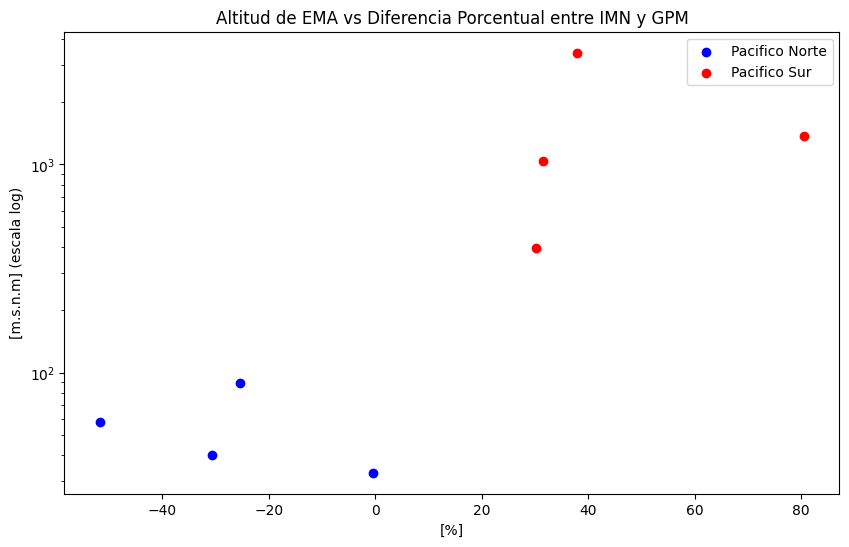

In [17]:
plt.figure(figsize=(10, 6))
# Define color map based on unique values in 'region_climatica'
colors = {'Pacifico Norte': 'b', 
          'Pacifico Sur':'r' 
          }
    
# Iterate through each region to create scatter plots with appropriate labels
for region, color in colors.items():
    region_data = meta_df[meta_df['region_climatica'] == region]
    plt.scatter(region_data['percentage_diff'], region_data['Altitud (m.s.n.m.)'], c=color, label=region)

plt.xlabel('[%]')
plt.ylabel('[m.s.n.m] (escala log)')
plt.title(f'Altitud de EMA vs Diferencia Porcentual entre IMN y GPM')
plt.legend()
plt.yscale('log') 
plt.savefig(f'./PLOTS/altitud_vs_diff_%_ST.png')
plt.show()

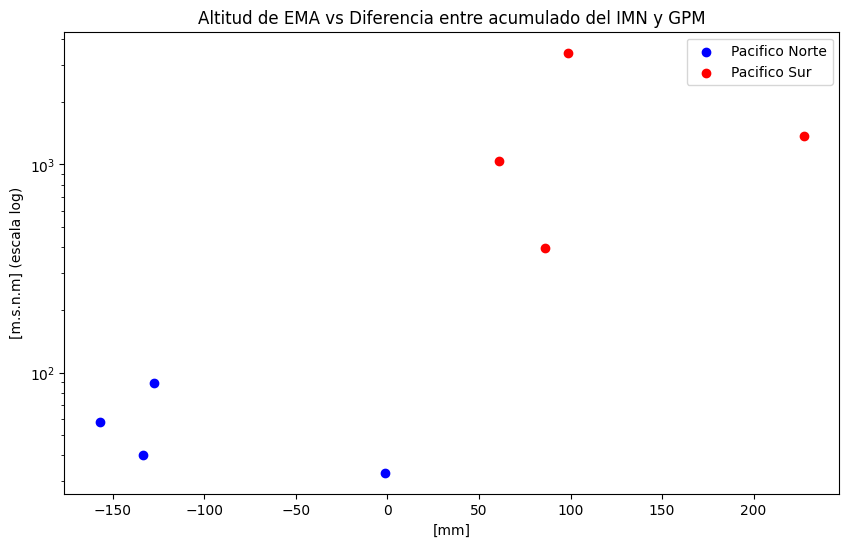

In [18]:
plt.figure(figsize=(10, 6))
# Define color map based on unique values in 'region_climatica'
colors = {'Pacifico Norte': 'b', 
          'Pacifico Sur':'r' 
          }
    
# Iterate through each region to create scatter plots with appropriate labels
for region, color in colors.items():
    region_data = meta_df[meta_df['region_climatica'] == region]
    plt.scatter(region_data['diff_accum'], region_data['Altitud (m.s.n.m.)'], c=color, label=region)

plt.xlabel('[mm]')
plt.ylabel('[m.s.n.m] (escala log)')
plt.title(f'Altitud de EMA vs Diferencia entre acumulado del IMN y GPM')
plt.legend()
plt.yscale('log') 
plt.savefig(f'./PLOTS/altitud_vs_diff_ST.png')
plt.show()